# Deformation of metric in a Euclidean geometry

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import pandas as pd
from itertools import combinations

In [150]:

# =========================================================
# Gaussian density
# =========================================================

def phi(x, center, sigma):
    r2 = np.sum((x-center)**2,axis=-1)
    #return 1 + (1/(2*np.pi*sigma**2))*np.exp(-r2/(2*sigma**2))
    return 1 + np.exp(-r2/(2*sigma**2))


# =========================================================
# General conformal deformation
# xi(x) = sum_i xi_i phi(x - z_i)
# =========================================================

def xi(x, centers, weights, sigma):
    val = 0
    for c,w in zip(centers,weights):
        val += w*phi(x,c,sigma)
    return val


# =========================================================
# Curve length
# =========================================================

def curve_length(points, centers, weights, sigma,
                 lam_curv=5.0,
                 lam_speed=1.0):

    p = points[:-1]
    q = points[1:]

    mid = 0.5*(p+q)

    ds = np.linalg.norm(q-p,axis=1)

    xi_vals = xi(mid,centers,weights,sigma)

    length = np.sum(xi_vals*ds)

    # ============================
    # curvature penalty
    # ============================

    accel = np.diff(points,2,axis=0)

    curvature_penalty = np.sum(np.linalg.norm(accel,axis=1)**2)

    # ============================
    # speed regularization
    # ============================

    speed = np.linalg.norm(np.diff(points,axis=0),axis=1)

    speed_penalty = np.sum((speed-np.mean(speed))**2)

    return length + lam_curv*curvature_penalty + lam_speed*speed_penalty

# =========================================================
# Geodesic computation
# =========================================================

def geodesic_distance(x1,x2,centers,weights,sigma,
                      n_points=40,
                      lam_curv=20.0,
                      lam_speed=5.0):

    t = np.linspace(0,1,n_points)

    curve = np.outer(1-t,x1)+np.outer(t,x2)

    x0 = curve[1:-1].flatten()

    def objective(v):

        pts = np.vstack([x1,v.reshape(-1,2),x2])

        return curve_length(pts,centers,weights,sigma,
                            lam_curv,lam_speed)

    res = minimize(objective,x0,method="L-BFGS-B")

    pts = np.vstack([x1,res.x.reshape(-1,2),x2])

    dist = curve_length(pts,centers,weights,sigma,
                        lam_curv,lam_speed)

    return dist,pts

# =========================================================
# Theoretical approximation
# =========================================================

def theoretical_distance(x1,x2,centers,weights,sigma):

    h = np.linalg.norm(x2-x1)

    xi1 = xi(x1,centers,weights,sigma)
    xi2 = xi(x2,centers,weights,sigma)

    return 0.5*(xi1+xi2)*h

# Relative distance between geodesic and line 
def line_geodesic_distance(path, x1, x2, relative=True, n_samples=200):

    t = np.linspace(0,1,n_samples)
    line = np.outer(1-t,x1) + np.outer(t,x2)
    

    d1 = np.max([np.min(np.linalg.norm(p-line,axis=1)) for p in path])
    d2 = np.max([np.min(np.linalg.norm(p-path,axis=1)) for p in line])

    d = max(d1,d2)

    if relative:
        d /= np.linalg.norm(x2-x1)

    return d

# =========================================================
# Experiment
# =========================================================

def run_experiment(points,weights,sigma):

    centers = points

    results = []

    paths = {}

    for i,j in combinations(range(len(points)),2):

        x1 = points[i]
        x2 = points[j]

        d_euclid = np.linalg.norm(x2-x1)

        d_geo,path = geodesic_distance(x1,x2,centers,weights,sigma)

        d_theory = theoretical_distance(x1,x2,centers,weights,sigma)

        err = abs(d_geo-d_theory)/d_geo

        curve_dev = line_geodesic_distance(path,x1,x2)

        results.append({
            "pair":f"{i}-{j}",
            "euclidean":d_euclid,
            "geodesic":d_geo,
            "approximation":d_theory,
            "relative_error":err,
            "curve_deviation":curve_dev
        })

        paths[(i,j)] = path

    df = pd.DataFrame(results)

    return df,paths

# =========================================================
# Visualization
# =========================================================

def plot_geometry(points,weights,sigma,paths, fsize=(10,6)):
    offset = 0.75
    xmin,xmax = points[:,0].min()-offset,points[:,0].max()+offset
    ymin,ymax = points[:,1].min()-offset,points[:,1].max()+offset

    xx = np.linspace(xmin,xmax,200)
    yy = np.linspace(ymin,ymax,200)

    X,Y = np.meshgrid(xx,yy)

    grid = np.stack([X,Y],axis=-1)

    Xi = xi(grid,points,weights,sigma)

    plt.figure(figsize=fsize)

    plt.contourf(X,Y,Xi,levels=40,cmap="Blues_r")
    plt.colorbar(label=r"$\xi(x)$")

    first_line = True
    first_geo = True

    for (i,j),path in paths.items():

        p1 = points[i]
        p2 = points[j]

        plt.plot([p1[0],p2[0]],[p1[1],p2[1]],
                 'w--',alpha=0.7,
                 label="Euclidean segment" if first_line else None)

        plt.plot(path[:,0],path[:,1],'y',
                 label="Geodesic" if first_geo else None)

        first_line = False
        first_geo = False

    plt.scatter(points[:,0],points[:,1],
                c="black",zorder=10,label="Points")

    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    #plt.title("Geodesics under conformal metric")
    plt.show()

# Examples

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  0-1        2.0  2.775993            3.6        0.296833         0.012811


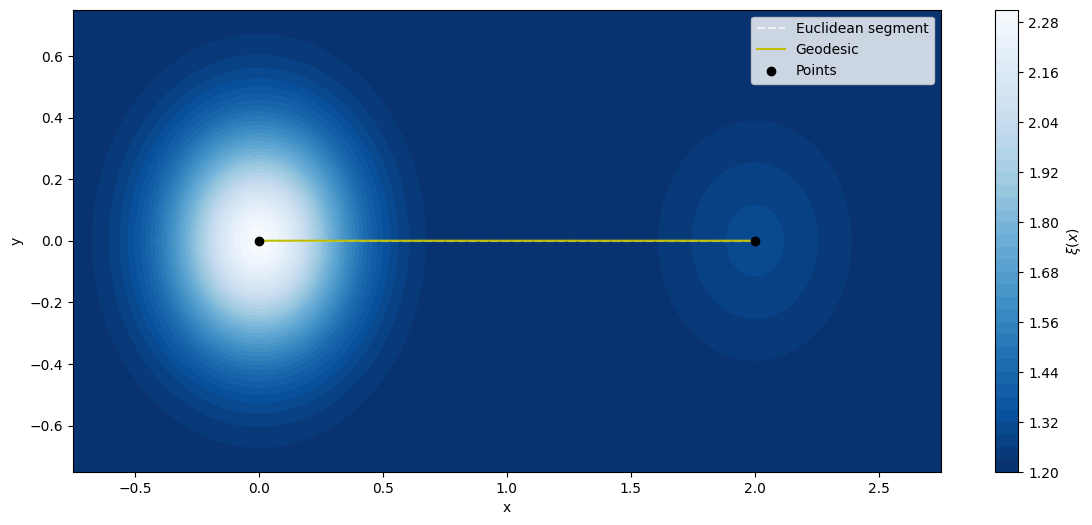

In [151]:
# =========================================================
# Example
# =========================================================

points = np.array([
[0,0], [2.0,0.0]
])

weights = np.array([1.1, 0.1])

sigma = 0.25


df,paths = run_experiment(points,weights,sigma)

print(df)

plot_geometry(points,weights,sigma,paths, fsize=(14,6))

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  0-1   1.011187  4.270492       4.626700        0.083411         0.012667
1  0-2   2.000000  8.513222       9.200981        0.080787         0.119613
2  1-2   1.011187  4.803093       5.486209        0.142224         0.012677


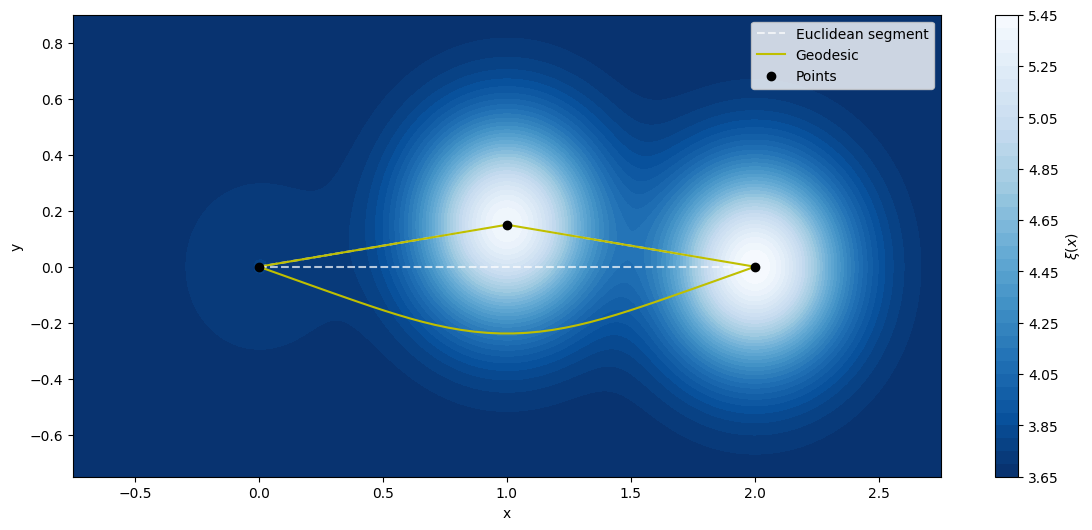

In [ ]:
# =========================================================
# Example
# =========================================================

points = np.array([
[0,0], [1.0,0.15], [2.0,0.0]
])

weights = np.array([0.1, 1.5, 1.8])

sigma = 0.25


df,paths = run_experiment(points,weights,sigma)

print(df)

plot_geometry(points,weights,sigma,paths, fsize=(14,6))

  pair  euclidean  geodesic  approximation  relative_error  curve_deviation
0  0-1   0.538516  3.051005       3.030677        0.006663         0.012755
1  0-2   1.513275  7.596709       8.442088        0.111282         0.070300
2  0-3   2.000000  9.988850       9.894821        0.009413         0.038670
3  1-2   1.077033  5.478272       6.202745        0.132245         0.012778
4  1-3   1.513275  7.293067       7.759808        0.063998         0.070530
5  2-3   0.538516  2.747457       2.734958        0.004549         0.012759


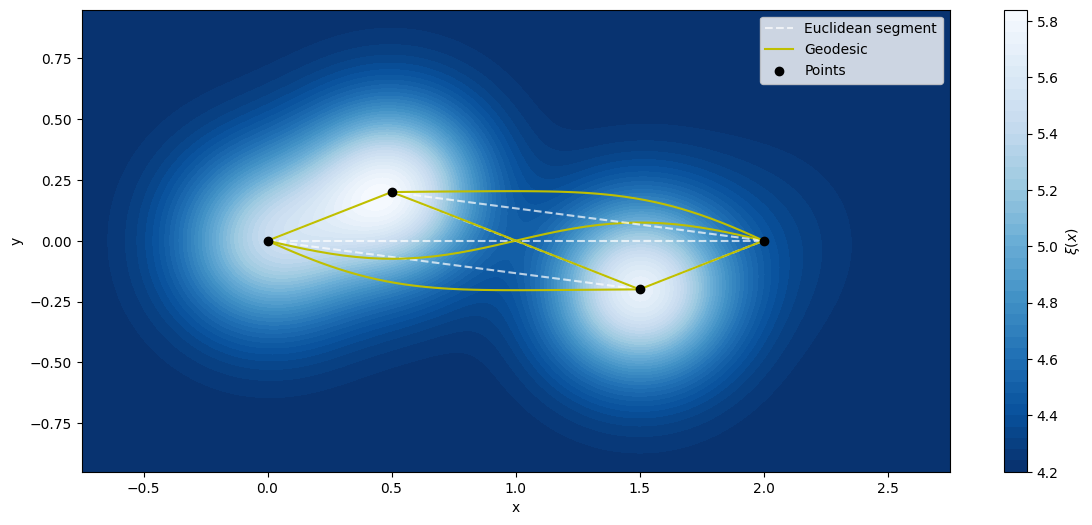

In [ ]:
# =========================================================
# Example
# =========================================================

points = np.array([
[0,0], [0.5,0.2], [1.5,-0.2], [2.0,0.0]
])

weights = np.array([1.1, 1.5, 2.0, 0.1])

sigma = 0.25


df,paths = run_experiment(points,weights,sigma)

print(df)

plot_geometry(points,weights,sigma,paths, fsize=(14,6))

  pair  euclidean   geodesic  approximation  relative_error  curve_deviation
0  0-1   0.707107   5.204830       5.364823        0.030739         0.012737
1  0-2   1.001249   6.782978       7.175256        0.057833         0.027475
2  0-3   1.513275  10.404520      11.862951        0.140173         0.032941
3  0-4   2.000000  13.596693      13.924349        0.024098         0.057939
4  1-2   0.672681   4.616467       4.726037        0.023734         0.012815
5  1-3   1.220656   8.596425       9.397371        0.093172         0.017333
6  1-4   1.581139  10.336893      10.785805        0.043428         0.062664
7  2-3   0.559017   4.066474       4.068483        0.000494         0.012765
8  2-4   1.001249   6.817177       6.408836        0.059899         0.072406
9  3-4   0.538516   3.820010       3.809356        0.002789         0.012781


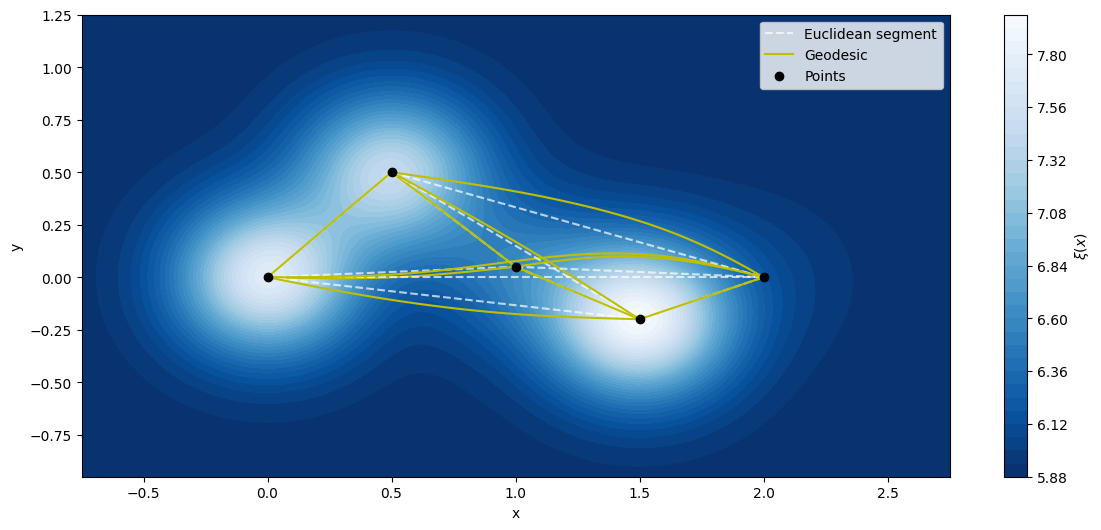

In [172]:
# =========================================================
# Example
# =========================================================

points = np.array([
[0,0], [0.5,0.5], [1.0,0.05], [1.5,-0.2], [2.0,0.0]
])

weights = np.array([1.8, 1.5, 0.5, 2.0, 0.1])

sigma = 0.25


df,paths = run_experiment(points,weights,sigma)

print(df)

plot_geometry(points,weights,sigma,paths, fsize=(14,6))

# Some experiments

In [101]:
xi_values = [0.5,1.0,2.0]
sigma_values = [1e-1,1e0,1e1]
from itertools import product, combinations
def generate_weight_grid(n_points):

    configs = list(product(xi_values, repeat=n_points))

    return np.array(configs)

def run_grid_experiment(points):

    centers = points
    n = len(points)

    weight_configs = generate_weight_grid(n)

    results = []

    for sigma in sigma_values:

        for weights in weight_configs:

            weights = np.array(weights)

            for i,j in combinations(range(n),2):

                x1 = points[i]
                x2 = points[j]

                d_e = np.linalg.norm(x2-x1)

                d_geo,path = geodesic_distance(
                    x1,x2,
                    centers,
                    weights,
                    sigma
                )

                d_th = theoretical_distance(
                    x1,x2,
                    centers,
                    weights,
                    sigma
                )

                err = abs(d_geo-d_th)/d_geo

                dev = line_geodesic_distance(path,x1,x2)

                results.append({
                    "sigma":sigma,
                    "weights":tuple(weights),
                    "pair":f"{i}-{j}",
                    "euclidean":d_e,
                    "geodesic":d_geo,
                    "approx":d_th,
                    "error":err,
                    "deviation":dev
                })

    return pd.DataFrame(results)

df = run_grid_experiment(points)

print(df.head())

   sigma          weights pair  euclidean  geodesic     approx     error  \
0    0.1  (0.5, 0.5, 0.5)  0-1   2.061553  3.217655   4.123106  0.281401   
1    0.1  (0.5, 0.5, 0.5)  0-2   4.000000  6.125313   8.000000  0.306056   
2    0.1  (0.5, 0.5, 0.5)  1-2   2.061553  3.217655   4.123106  0.281401   
3    0.1  (0.5, 0.5, 1.0)  0-1   2.061553  4.248431   5.153882  0.213126   
4    0.1  (0.5, 0.5, 1.0)  0-2   4.000000  8.187951  11.000000  0.343437   

   deviation  
0   0.012753  
1   0.012752  
2   0.012753  
3   0.012753  
4   0.012753  


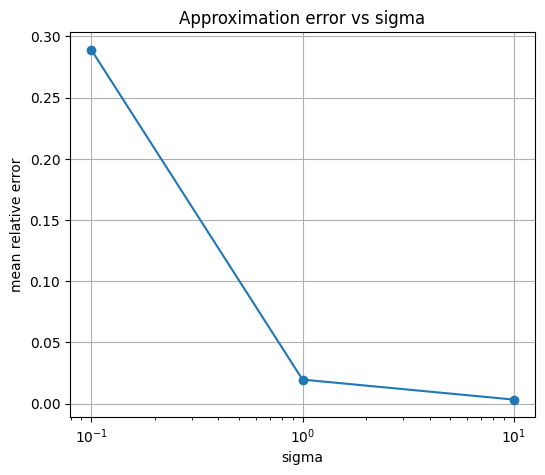

In [105]:
def plot_error_vs_sigma(df):

    grouped = df.groupby("sigma")["error"].mean()

    plt.figure(figsize=(6,5))

    plt.semilogx(grouped.index, grouped.values,'o-')

    plt.xlabel("sigma")
    plt.ylabel("mean relative error")

    plt.title("Approximation error vs sigma")

    plt.grid(True)

    plt.show()
plot_error_vs_sigma(df)

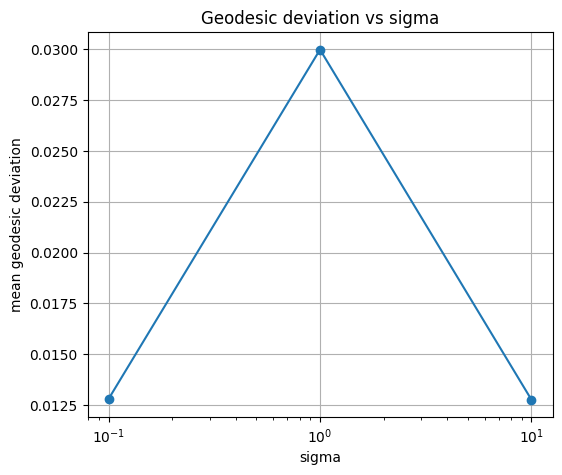

In [106]:
def plot_deviation_vs_sigma(df):

    grouped = df.groupby("sigma")["deviation"].mean()

    plt.figure(figsize=(6,5))

    plt.semilogx(grouped.index, grouped.values,'o-')

    plt.xlabel("sigma")
    plt.ylabel("mean geodesic deviation")

    plt.title("Geodesic deviation vs sigma")

    plt.grid(True)

    plt.show()

plot_deviation_vs_sigma(df)

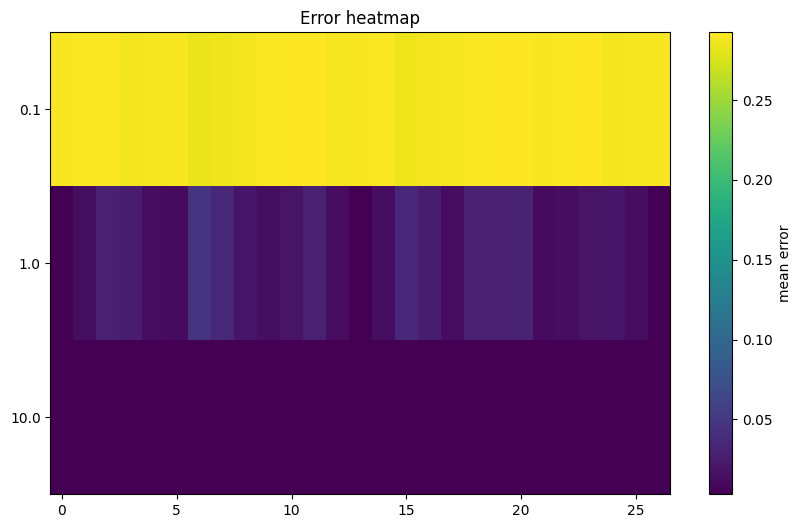

In [107]:
def heatmap_error(df):

    pivot = df.pivot_table(
        values="error",
        index="sigma",
        columns="weights",
        aggfunc="mean"
    )

    plt.figure(figsize=(10,6))

    plt.imshow(pivot,aspect="auto")

    plt.colorbar(label="mean error")

    plt.yticks(range(len(pivot.index)),pivot.index)

    plt.title("Error heatmap")

    plt.show()

heatmap_error(df)